##### make_pct_heat:
Metric: total non-gen-ed courses that are required for a BS in CS that could articulate to a 4y / total non-gen-ed courses that are required for a BS in CS
Format: %

Assumptions: 
- The student is not trying for an AS -- rather, they are trying to maximize transfer credits
- No course has any pre/co requisites

##### make_sem_heat:
Metric: total non-gen-ed courses that are required for a BS in CS that could articulate to a 4y / 4

Assumptions: 
- Each semeseter consists of 4 courses
- Each course counts for the same (except labs which I bundled with their main course)

Note: Schools in MassTransfer garuntee 2 years will articulate. The reason these results differ is because my analysis excludes gen-eds. MCLA, for example, has a substantial amount of gen-eds, meaning that 60 credits can transfer while very few major specific courses do. 

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_ALL = "Four-Year Heatmap.xlsx"
# RAW_CS = "CS Mass Heatmap.xlsx"
UNI_LIST = ['Bridgewater', 'Fitchburg', 'Framingham', 'MCLA', 'Salem', 'UMass Amherst', 'UMass Boston', 'UMass Lowell', 'UMass Dartmouth', 'Westfield', 'Worcester']

In [81]:
def make_df(data, title):
    df = pd.DataFrame()
    for uni in UNI_LIST:
        # Articulation
        art_df = pd.read_excel(data, uni)[:16][['Unnamed: 0', title]]
        art_df.rename(columns={'Unnamed: 0': 'Community Colleges'}, inplace=True)
        art_df.set_index('Community Colleges', inplace=True)

        art_df.rename(columns={title: uni}, inplace=True)
        art_df = pd.to_numeric(art_df[uni], errors='coerce')

        df = pd.concat([df, art_df], axis=1)
        df.rename(index={'nan': 'total'})

    return df

In [82]:
def make_pct_heat(df, title, filename):
    no_total = df.copy().drop('Total', axis=0)
    no_total.loc['Average'] = no_total.mean()
    ax = sns.heatmap(no_total, fmt='.0%', annot=True, cmap='Greens', vmax=1, linewidths=.5, linecolor='darkgreen')

    n_rows = len(no_total)

    # Thin separator above the Average row
    ax.axhline(y=n_rows - 1, color='black', linewidth=1)

    # Bold the 'Average' y-axis tick label
    for label in ax.get_yticklabels():
        if label.get_text() == 'Average':
            label.set_fontweight('bold')

    # Color the borders
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('darkgreen')

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.title(f'{title}\n')
    plt.ylabel('Community Colleges')
    plt.xlabel('Public 4 Years')
    plt.savefig(f'images/{filename}.png', bbox_inches='tight')
    plt.show()

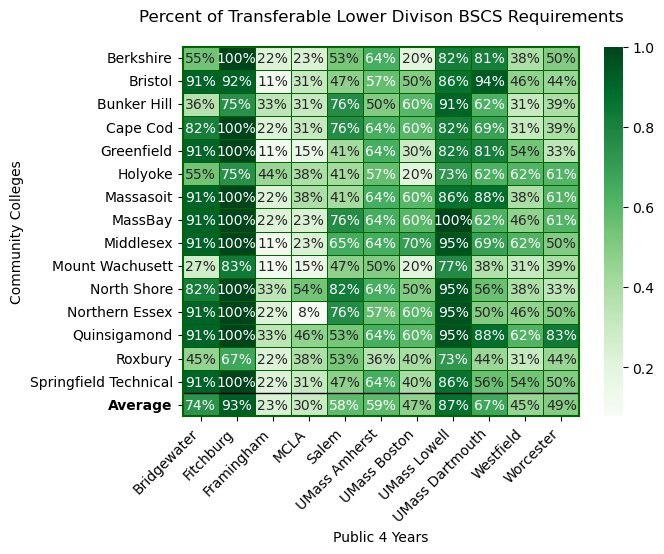

In [83]:
lower_df = make_df(RAW_ALL, 'Lower')
make_pct_heat(lower_df, 'Percent of Transferable Lower Divison BSCS Requirements', 'lowdiv_heatmap')
#make_sem_heat(lower_df, 'Total Lower Division Semesters that Articulate From Community Colleges')


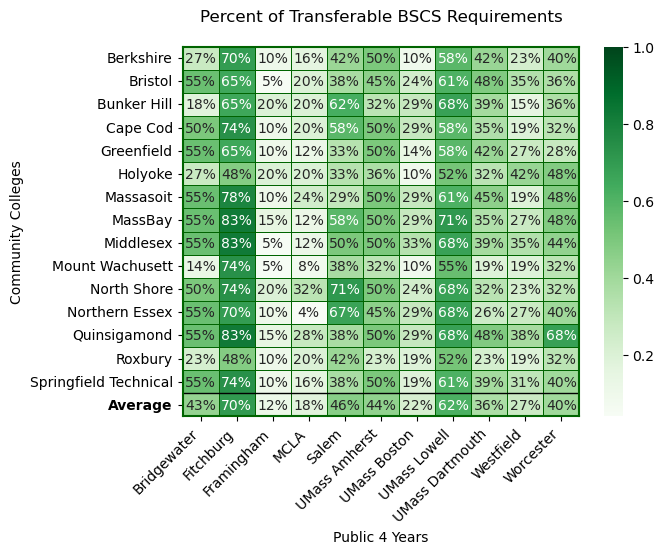

In [84]:
upper_df = make_df(RAW_ALL, 'Upper')
make_pct_heat(upper_df, 'Percent of Transferable BSCS Requirements', 'all_heatmap')
# make_sem_heat(upper_df, 'Lower + Upper Division Semesters that Articulate to Mass Public Universities')

In [85]:
# def make_sem_heat(df, title, filename):
#     for uni in UNI_LIST:
#         df.loc[:, uni] *= df.loc[:, uni].loc['Total']
#         df.loc[:, uni] /= 4
    
#     sns.heatmap(df.loc[:'Springfield Technical'], fmt='.1f', annot=True, cmap='Greens', vmax=4)
#     plt.title(f'{title}\n')
#     plt.ylabel('Community Colleges')
#     plt.xlabel('Public 4 Years')
#     plt.savefig(f'images/{filename}.png', bbox_inches = 'tight')
#     plt.show()
     

In [86]:
# Just CS Courses
#lower_df = make_df(RAW_CS, 'Lower')
# make_heat(lower_df, '% of Lower Division Required Courses in CS that Articulate to Mass Public Univsersities', 1)
#low_years = lower_df * 2
#make_heat(low_years, 'Total Lower Division -CS- School Years that Articulate to Mass Public Universities', 2)

In [87]:
#Just CS Courses
#upper_df = make_df(RAW_ALL, 'Upper')
# make_heat(lower_df, '% of Required Courses that Articulate to Mass Public Univsersities', 1)
#up_years = upper_df * 2
#make_heat(up_years, 'Lower + Upper Division -CS- School Years that Articulate to Mass Public Universities', 4)